In [1]:
%load_ext autoreload
%autoreload 2

from IPython.display import Math, Latex

import pandas as pd, cvxpy as cp, numpy as np, matplotlib as mpl  # type: ignore
import matplotlib.pyplot as plt  # type: ignore

from matplotlib.ticker import FuncFormatter, MultipleLocator  # type: ignore
from matplotlib.patches import FancyArrowPatch, Polygon  # type: ignore
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

from scipy.integrate import quad  # type: ignore
from scipy.spatial import ConvexHull
from scipy.interpolate import interp1d

import importlib, itertools, csv, concurrent.futures
import os, math, sys, json, pickle, shutil, time, functools

from typing import Dict, List, Any, Optional, Literal
from tqdm.notebook import tqdm
import networkx as nx

from Utils import Notebook, tex, gph, sgn, nm, ds
from Simulator import *
# from SimulatorOld import *
from optimization import DisturbedSaturatedPETC as DSPETC

cfg = {
    'style': {'color': 'black'},
    'axis': {
        'title_pad': 10,
        'x_label_fontsize': 16,
        'y_label_fontsize': 16,
        'tick_fontsize': 16,
    },
    'legend': {'fontsize': 16}
}

colors_list = plt.get_cmap('tab20').colors
Notebook.setup()

LaTeX has been enabled for text rendering.


### Definição da Planta

In [2]:
experiment_filename = 'exp-03'

with open(f"experiment-datas/{experiment_filename}.json", encoding='utf-8') as f:
  exp_data = json.load(f)

plant = ds.StateSpace(data=exp_data["plant"], name='plant')
latex_expr = plant.get_latex_equations()
print("Equações que regem a dinâmica da planta:")
tex.display_latex(latex_expr)

Equações que regem a dinâmica da planta:


<IPython.core.display.Latex object>

### Simulação da Planta em Malha Aberta

In [3]:
import Simulator
import matplotlib.pyplot as plt

# Parâmetros
EXPERIMENT_FILE = f"experiment-datas/{experiment_filename}.json"
x0 = [-0.87157554, 0.49026124]

y_hist, t_hist, u_hist = Simulator.open_loop(
    x0, EXPERIMENT_FILE, u_constant=0.0)

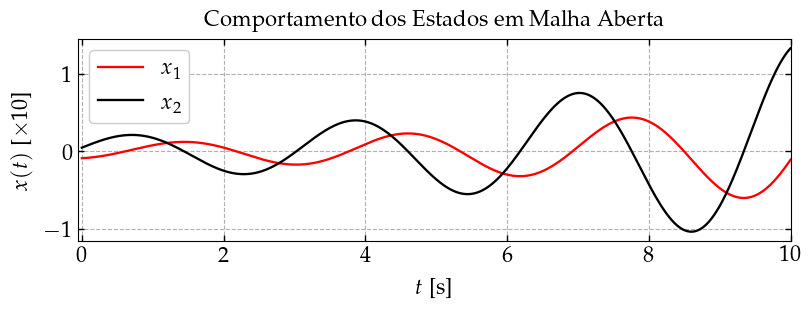

In [4]:
fig = plt.figure(figsize=(8, 3), layout='constrained')
axs = fig.subplot_mosaic([["x"]])

_ = gph.plot(
    axs['x'], t_hist, y_hist,
    xlabel='$t$', x_unit='s', x_use_prefixes=True,
    ylabel=r'$x(t)$', color=['red', 'black'],
    label=[fr'$x_1$', fr'$x_2$'],
    cfg=cfg, title='Comportamento dos Estados em Malha Aberta',
    x_pad=(0.005, 0.0), y_pad=(0.05, 0.05)
)

### Projeto do Controlador e do ETM

In [5]:
def solve_problem(
    h: float,
    υ: float,
    eps: float = 1e-6,
    σ: float = 0.0,
    εtr: float = 0.0,
    K: np.array = None
):
  n_x = plant.nx
  n_u = plant.nu

  Onx = np.zeros((n_x, n_x))

  matrices = plant.evaluate_matrices(None, None, None)
  A = matrices['A']
  B = matrices['B']

  e = nm.get_e(5 * [n_x])

  for i in range(1, len(e)):
    e[i] = cp.Parameter(e[i].shape, value=e[i], name=f"e{i}")

  constraints = []

  Ptil = cp.Variable((n_x, n_x), PSD=True)
  Mtil = cp.Variable((2 * n_x, 2 * n_x), PSD=True)
  Q1til = cp.Variable((n_x, n_x), symmetric=True)
  Q2til = cp.Variable((n_x, n_x))
  Q3til = cp.Variable((n_x, n_x))
  S1til = cp.Variable((n_x, n_x), symmetric=True)
  S2til = cp.Variable((n_x, n_x))
  S3til = cp.Variable((n_x, n_x))

  if K is None:
    Ktil = cp.Variable((n_u, n_x))
  else:
    Ktil = cp.Parameter((n_u, n_x), value=K)

  Rtil = cp.Variable((n_x, n_x), PSD=True)
  Ξtil = cp.Variable((n_x, n_x), PSD=True)
  # Ξtil = cp.Parameter((n_x, n_x), value=np.eye(n_x))

  if σ == 0.0:
    Ψtil = cp.Variable((n_x, n_x), PSD=True)
    # Ψtil = cp.Parameter((n_x, n_x), value=np.eye(n_x))

  X = cp.Variable((n_x, n_x))
  Ytil = cp.Variable((2 * n_x, e[1].shape[1]))

  Rcal = cp.bmat([[Rtil, Onx],
                  [Onx, 3. * Rtil]])

  Fscr = e[1].T + υ * e[2].T + υ * e[4].T

  κ1 = cp.bmat([[e[2]], [e[5]]])
  κ2 = cp.bmat([[e[1] - e[2]],
                [e[1] + e[2] - 2. * e[3]]])

  def get_Θ(ω):
    if K is None:
      Bscr = A @ X @ e[1] + B @ Ktil @ e[2] + \
          B @ Ktil @ e[5] - X @ e[4]
    else:
      Bscr = A @ X @ e[1] + B @ Ktil @ X @ e[2] + \
          B @ Ktil @ X @ e[5] - X @ e[4]
    Θ1 = (e[1] - e[2]).T @ S1til @ (e[1] - e[2]) + \
        nm.He((e[1] - e[2]).T @ (S2til @ e[2] + S3til @ e[5]))
    Θ2 = nm.He(e[3].T @ (Q2til @ e[2] + Q3til @ e[5]))
    Θ3 = nm.He(e[1].T @ (Q1til @ e[3] + Q2til @ e[2] + Q3til @ e[5]))
    Θ4 = nm.He(e[4].T @ (S1til @ (e[1] - e[2]) + S2til @
               e[2] + S3til @ e[5])) + e[4].T @ Rtil @ e[4]
    return nm.He(e[1].T @ Ptil @ e[4] + Fscr @ Bscr - κ2.T @ Ytil) - e[5].T @ Ξtil @ e[5] - \
        Θ1 - ω * Θ2 - h * e[3].T @ Q1til @ e[3] + \
        (h - ω) * Θ3 + (h - 2.0 * ω) * κ1.T @ Mtil @ κ1 + \
        (h - ω) * Θ4 + σ * e[2].T @ Ξtil @ e[2]

  def get_Γ():
    Γ1_11 = get_Θ(0)
    Γ1 = Γ1_11

    if σ == 0.0:
      Γ1_12 = e[2].T @ X.T

      Γ1_21 = Γ1_12.T
      Γ1_22 = - Ψtil

      Γ1 = cp.bmat([[Γ1_11, Γ1_12],
                    [Γ1_21, Γ1_22]])

    Γ2_11 = get_Θ(h)
    Γ2_12 = Ytil.T

    Γ2_21 = Γ2_12.T
    Γ2_22 = - (1. / h) * Rcal

    Γ2 = cp.bmat([[Γ2_11, Γ2_12],
                  [Γ2_21, Γ2_22]])

    if σ == 0.0:
      Γ2_13 = e[2].T @ X.T
      Γ2_23 = np.zeros((2 * n_x, n_x))
      Γ2_31 = Γ2_13.T
      Γ2_32 = Γ2_23.T
      Γ2_33 = - Ψtil

      Γ2 = cp.bmat([[Γ2_11, Γ2_12, Γ2_13],
                    [Γ2_21, Γ2_22, Γ2_23],
                    [Γ2_31, Γ2_32, Γ2_33]])

    return Γ1, Γ2

  Γ1, Γ2 = get_Γ()
  constraints += [Γ1 << -eps * np.eye(Γ1.shape[0])]
  constraints += [Γ2 << -eps * np.eye(Γ2.shape[0])]

  constraints += [Ξtil >> eps * np.eye(n_x)]
  if σ == 0.0:
    constraints += [Ψtil >> eps * np.eye(n_x)]

  if σ == 0.0:
    if εtr == 0.0:
      obj = cp.Minimize(cp.trace(Ξtil + Ψtil))
    else:
      constraints += [cp.trace(Ξtil + Ψtil) <= εtr]
      obj = cp.Minimize(0.0)
  else:
    obj = cp.Minimize(0.0)
  prob = cp.Problem(obj, constraints)

  try:
    # Tenta resolver o problema de otimização
    prob.solve(solver=cp.MOSEK, verbose=False, ignore_dpp=True)

    # Verifica o status do solver após a execução
    if prob.status in ["infeasible", "unbounded"]:
      # O solver terminou, mas o problema é infactível ou ilimitado
      return None

    # Se chegou aqui, o solver obteve sucesso. Processa e retorna os resultados.
    Xinv = np.linalg.inv(X.value)
    Ξ = Xinv.T @ Ξtil.value @ Xinv
    # Ξ = Ξtil.value
    matrix_trace = np.trace(Ξtil.value + Ψtil.value) if σ == 0.0 else None
    if σ == 0.0:
      Ψ = np.linalg.inv(Ψtil.value)
    else:
      Ψ = σ * Ξ
    P = Xinv.T @ Ptil.value @ Xinv
    S2 = Xinv.T @ S2til.value @ Xinv

    if K is None:
      K = Ktil.value @ Xinv

    etm_results = {'Ξ': Ξ, 'Ψ': Ψ}
    design_results = {
        'optimal_value': prob.value,
        'matrix_trace': matrix_trace,
        'etm': etm_results,
        'controller': {'K': K},
        'lyapunov': [P, S2],
    }
    return design_results

  except cp.error.SolverError:
    # O solver falhou com um erro (ex: problemas numéricos)
    return None

In [ ]:
sampling_period = exp_data["design_params"]['h']
υ = 1e-2

prob_results = solve_problem(h=sampling_period, υ=υ, σ=0.9)

if prob_results is not None:
  matrix_trace = prob_results['matrix_trace']
  Ξ, Ψ = prob_results['etm']['Ξ'], prob_results['etm']['Ψ']
  K = prob_results['controller']['K']
  P, S2 = prob_results['lyapunov']

  display(Math(rf'{{\rm tr}}(\tilde\Xi + \tilde\Psi) = {matrix_trace}'))
  display(Math(rf'\Xi = {tex.mat2tex(Ξ)}'))
  display(Math(rf'\Psi = {tex.mat2tex(Ψ)}'))
  display(Math(rf'P = {tex.mat2tex(P)}'))

  display(Math(rf'K = {tex.mat2tex(K)}'))
else:
  print("No results.")

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

### Simulação do Sistema em Malha Fechada

In [7]:
%%skip prob_results is None

x0 = [0.8, 0.8]

y_hist, t_hist, u_hist, events = closed_loop_setm(
    x0, EXPERIMENT_FILE, prob_results)

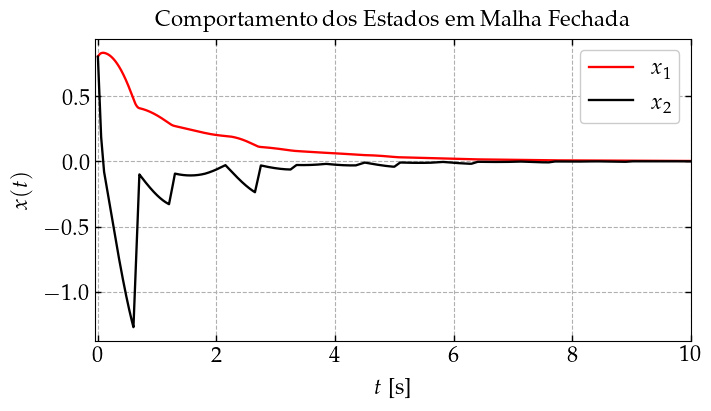

In [8]:
fig = plt.figure(figsize=(7, 4), layout='constrained')
axs = fig.subplot_mosaic([["x"]])

_ = gph.plot(
    axs['x'], t_hist, y_hist,
    xlabel='$t$', x_unit='s', x_use_prefixes=True,
    ylabel=r'$x(t)$', color=['red', 'black'],
    label=[fr'$x_1$', fr'$x_2$'],
    cfg=cfg, title='Comportamento dos Estados em Malha Fechada',
    x_pad=(0.005, 0.0), y_pad=(0.05, 0.05)
)

Economia: 84.00%


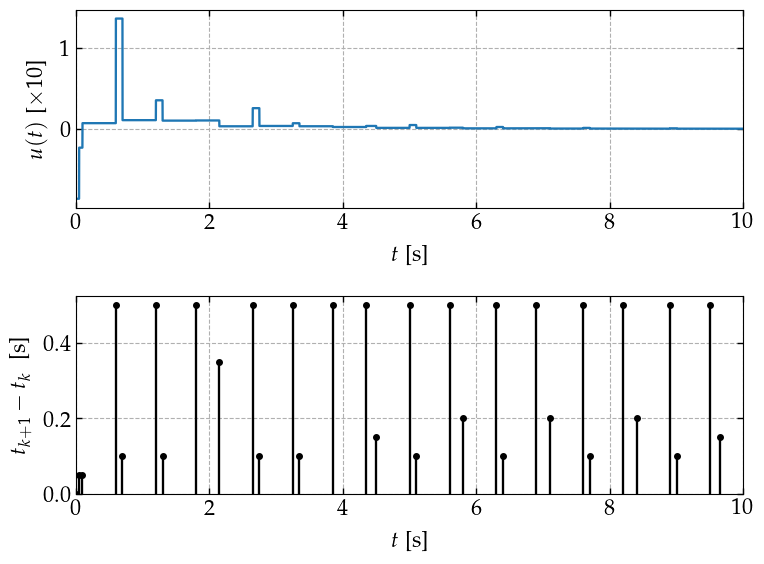

In [9]:
mosaic = [['control'], ['iet']]
fig, axs = plt.subplot_mosaic(mosaic, figsize=(8, 6))

inter_event_times = nm.compute_deltas(events)
ks_iet = np.round(
    np.array(inter_event_times) / sampling_period).astype(int).tolist()

simulation_time = exp_data["duration"]
sampling_time = exp_data["design_params"]['h']
n_samples = simulation_time / sampling_time
saving = 100.0 * (1.0 - len(events) / (n_samples))
print("Economia:", f"{saving:.2f}%")

for i in range(plant.nu):
  gph.plot(
      axs['control'], t_hist, u_hist, xlabel='$t$', x_unit='s', x_use_prefixes=True,
      ylabel=r'$u(t)$', y_pad=(0.05, 0.05),
      cfg={**cfg, 'style': {'color': colors_list[0], "linestyle": ["-"], }},)

gph.stem(
    axs['iet'], events, inter_event_times,
    reuse_previous=False, y_pad=(0.0, 0.05), x_use_prefixes=True,
    xlabel='$t$', x_unit='s', x_range=(0.0, t_hist[-1]),
    ylabel='$t_{k+1} - t_k\\;$', y_unit='s', y_use_prefixes=True,
    cfg={**cfg, 'limits': {'x_min': 0, 'x_max': t_hist[-1]}})

plt.tight_layout(pad=2.)

### Construção do Modelo de Tráfego

In [10]:
%%skip

def build_symbolic_graph(l, eps, config_path, prob_results):
  """
  Constructs the DiGraph based on parallel symbolic sequences.
  """
  initial_states, _ = projective_eps_net(eps)
  G = nx.DiGraph()

  all_k_seqs = build_symbolic_sequences_parallel(
      initial_states, config_path, prob_results
  )

  for k_seq in all_k_seqs:
    if len(k_seq) > l:
      for i in range(len(k_seq) - l):
        state_curr = tuple(k_seq[i: i + l])
        state_next = tuple(k_seq[i + 1: i + l + 1])
        G.add_edge(state_curr, state_next, weight=state_curr[0])

  return G, initial_states


L_WORD = 10
EPSILON = 1e-3

G_sampled, states = build_symbolic_graph(
    L_WORD, EPSILON, EXPERIMENT_FILE, prob_results)

print(
    f"Nodes: {G_sampled.number_of_nodes()} | Edges: {G_sampled.number_of_edges()}")

Cell skipped (unconditional).


In [11]:
%%skip

k_sequence_raw = np.round(
    np.array(inter_event_times[1:]) / sampling_period).astype(int).tolist()
sequence_nodes = [tuple(k_sequence_raw[i: i + L_WORD])
                  for i in range(len(k_sequence_raw) - L_WORD + 1)]

visualize_graph(G_sampled, sequence_nodes, "sampled_model.html")

Cell skipped (unconditional).


In [17]:
h = sampling_period
iet_max = exp_data["design_params"]['iet_max']
K_set = [i + 1 for i in range(int(round(iet_max / h)))]
print("K_set:", K_set)

Ξ = prob_results['etm']['Ξ']
Ψ = prob_results['etm']['Ψ']
K_control = prob_results['controller']['K']
A, B, _, _ = plant.export_matrices_jit()


print("h:", h)
print("iet_max:", iet_max)
display(Math(rf'A = {tex.mat2tex(A)}'))
display(Math(rf'B = {tex.mat2tex(B)}'))

display(Math(rf'\Xi = {tex.mat2tex(Ξ)}'))
display(Math(rf'\Psi = {tex.mat2tex(Ψ)}'))

L_WORD = 2
G_complete = build_symbolic_exactly_graph(
    target_l=L_WORD, K_set=K_set, h=h, A=A,
    B=B, K=K_control, Xi=Ξ, Psi=Ψ, iet_max=iet_max
)

print(
    f"\nGrafo gerado com {G_complete.number_of_nodes()} nós e {G_complete.number_of_edges()} arestas.")

K_set: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
h: 0.05
iet_max: 0.5


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

=== [Init] Pre-calculating dynamics (Z3 Backend) ===
--- Layer 1 ---
--- Layer 2 ---
   Candidates: 100 | Valid: 36
   Topological Pruning Avoided 0 SMT calls.
   Total Dropped: 64
=== [Edges] Generating edges (Extension to size 3) ===

=== Final Report ===
Final Nodes: 36
Edges:       63

Grafo gerado com 36 nós e 63 arestas.


In [ ]:
%%skip
visualize_graph(G_complete, sequence_nodes, "complete_model.html")

Cell skipped (unconditional).


In [18]:
iet_max = exp_data["design_params"]['iet_max']
h = sampling_period

A, B, _, _ = plant.export_matrices_jit()
K = prob_results['controller']['K']
Xi = prob_results['etm']['Ξ']
Psi = prob_results['etm']['Ψ']

sequence = (5, 5)

reconstructor = SequenceReconstructor(A, B, K, Xi, Psi, h, iet_max)

metrics = compute_analytical_metrics(
    G_complete, h, reconstructor, verbose=False)

In [19]:
metrics

{'NumNodes': 36,
 'NumEdges': 63,
 'Entropy': 3.8362335900731215,
 'Inf': 0.05,
 'Sup': 0.5,
 'InfLimInf': 0.05,
 'SupLimSup': 0.5,
 'InfLimAvg': np.float64(0.050000000000000044),
 'SupLimAvg': np.float64(0.050000000000000044),
 'RobInfLimAvg': None,
 'IsMACStable': False,
 'SavingsPct': np.float64(7.771561172376096e-14)}

### Obtenção da Região de Estados Inciais para Uma Sequência

In [ ]:
%%skip

print(f"=== Buscando estado inicial para a sequência: {sequence} ===")

x0_exact = reconstructor.find_compatible_state(sequence)

if x0_exact is not None:
  x0_exact_norm = x0_exact / np.linalg.norm(x0_exact)
  print(f"Estado inicial encontrado (norm): {x0_exact_norm}")

  x0_sim = x0_exact_norm

  _, _, _, events = closed_loop_setm(x0_sim, EXPERIMENT_FILE, prob_results)

  if len(events) > 1:
    inter_event_times = np.diff(events)
    k_simulated = inter_event_times / h

    print("\n--- Validação Cruzada (Simulador C++) ---")
    print("Obtido (k):", k_simulated[:len(sequence)])

    k_rounded = np.round(k_simulated[:len(sequence)]).astype(int)
    is_match = np.all(k_rounded == np.array(sequence))

    if is_match:
      print("Resultado: ✅ Sucesso!")
    else:
      print("Resultado: ⚠️ Divergência Numérica")
  else:
    print("Aviso: A simulação não gerou eventos suficientes para validar a sequência inteira.")

else:
  print(
      f"❌ A sequência {sequence} é fisicamente impossível para este sistema.")

Cell skipped (unconditional).


In [ ]:
# --- Angular Region Analysis ---
analyzer = SequenceRegionAnalyzer(reconstructor)
target_sequence = sequence
region_bounds = analyzer.find_region(target_sequence)

if region_bounds:
  print(f"The sequence occurs for θ in: {region_bounds} rad")

  # Conversion and interval width calculation
  for start_rad, end_rad in region_bounds:
    start_deg = np.degrees(start_rad)
    end_deg = np.degrees(end_rad)
    width_deg = end_deg - start_deg

    print(f"Bounds: [{start_deg:.4f}°, {end_deg:.4f}°]")
    print(f"Interval Width: {width_deg:.4f}°")
else:
  print("Impossible sequence (empty region).")

Impossible sequence (empty region).


In [ ]:
%%skip 
# len(region_bounds) == 0

radius = 2.0

x_border = []
y_border = []

for start, end in region_bounds:
  for offset in [0, np.pi]:
    for ang in [start + offset, end + offset]:
      x_border.extend([0, radius * np.cos(ang), 0])
      y_border.extend([0, radius * np.sin(ang), 0])

x_border = np.array(x_border)
y_border = np.array(y_border)

mosaic = [['x']]
fig, axs = plt.subplot_mosaic(mosaic, figsize=(8, 8))
ax = axs['x']

gph.plot(
    ax,
    x_data=x_border,
    y_data=y_border,
    xlabel='$x_1$',
    ylabel='$x_2$',
    title='Célula de Invariância Simbólica: Plano de Fase',
    cfg={**cfg, 'style': {'color': '#003366', 'linewidth': 2.0}},
    x_pad=(0, 0),
    y_pad=(0, 0)
)

ax.set_xlim(-1.0, 1.0)
ax.set_ylim(-1.0, 1.0)

ax.axhline(0, color='black', lw=1, zorder=1)
ax.axvline(0, color='black', lw=1, zorder=1)

for start, end in region_bounds:
  for offset in [0, np.pi]:
    s, e = start + offset, end + offset
    t_arc = np.linspace(s, e, 50)

    x_arc = np.concatenate([[0], radius * np.cos(t_arc), [0]])
    y_arc = np.concatenate([[0], radius * np.sin(t_arc), [0]])

    ax.fill(x_arc, y_arc, color='#00BFFF',
            alpha=0.3, edgecolor='none', zorder=0)

ax.set_aspect('equal', adjustable='box')
plt.tight_layout(pad=1.5)

Cell skipped (unconditional).


In [ ]:
%%skip

analyzer = SequenceRegionAnalyzer(reconstructor)
region_data = analyzer.find_region(target_sequence)

if region_data:
  for s, e in region_data:
    width = np.degrees(e) - np.degrees(s)
    print(
        f"Analytical Region Found: [{np.degrees(s):.4f}°, {np.degrees(e):.4f}°]")
    print(f"Angular Width (Robustness Δθ): {width:.4f}°\n")

  verify_region_robustness(
      target_seq=target_sequence,
      region_list=region_data,
      config=exp_data,
      prob_results=prob_results,
      experiment_file=EXPERIMENT_FILE,
      n_samples=1000,
      eps=1e-7
  )
else:
  print("Sequence is analytically impossible.")

Cell skipped (unconditional).


### Cálculo das Métricas do Modelo de Tráfego

In [ ]:
%%skip
l_start, l_stop = 7, 8

h = exp_data["design_params"]['h']
iet_max = 10 * h
k_max = int(round(iet_max / h))
A, B, _, _ = plant.export_matrices_jit()
K_set = [i + 1 for i in range(k_max)]

for l in range(l_start, l_stop):
  σs = [1e-6] + np.arange(0.005, 0.15, 0.005).tolist()
  # σs = [1.4e-1]
  for σ in σs:
    print("\r\033[2K",
          f"Calculando métricas para l = {l} e σ = {σ}", end="")
    prob_results = solve_problem(h=sampling_period, υ=υ, σ=σ)
    if prob_results:
      Ξ = prob_results['etm']['Ξ']
      Ψ = prob_results['etm']['Ψ']
      K = prob_results['controller']['K']
      reconstructor = SequenceReconstructor(A, B, K, Ξ, Ψ, h, iet_max)

      L_WORD = l

      G_complete = build_symbolic_exactly_graph(
          target_l=L_WORD, K_set=K_set, h=h, A=A,
          B=B, K=K, Xi=Ξ, Psi=Ψ, iet_max=iet_max, verbose=False,
      )

      dict = {"l_word": l, "sigma": σ}

      metrics = compute_analytical_metrics(
          G_complete, h, reconstructor, verbose=False)

      dict.update(metrics)

      export_metrics_to_csv(
          dict, f"etc-traffic-logs/escalar/kmax{k_max}_tmp.csv")
    else:
      print("-> fail")

 Calculando métricas para l = 7 e σ = 0.145000000000000026

In [ ]:
# %%skip

l_start, l_stop = 2, 3

h = exp_data["design_params"]['h']
# iet_max = exp_data["design_params"]['iet_max']
iet_max = 15 * h
k_max = int(round(iet_max / h))
A, B, _, _ = plant.export_matrices_jit()
K_set = [i + 1 for i in range(k_max)]

for l in range(l_start, l_stop):
  εtrs = np.logspace(-4, 2, 20)
  # εtrs = [7e-4]
  for εtr in εtrs:
    print("\r\033[2K",
          f"Calculando métricas para l = {l} e eps_tr = {εtr}", end="")
    prob_results = solve_problem(h=sampling_period, υ=υ, εtr=εtr)
    if prob_results:
      Ξ = prob_results['etm']['Ξ']
      Ψ = prob_results['etm']['Ψ']
      K = prob_results['controller']['K']
      reconstructor = SequenceReconstructor(A, B, K, Ξ, Ψ, h, iet_max)

      L_WORD = l

      G_complete = build_symbolic_exactly_graph(
          target_l=L_WORD, K_set=K_set, h=h, A=A,
          B=B, K=K, Xi=Ξ, Psi=Ψ, iet_max=iet_max, verbose=False,
      )

      dict = {"l_word": l, "eps_tr": εtr}

      metrics = compute_analytical_metrics(
          G_complete, h, reconstructor, verbose=False)

      dict.update(metrics)

      export_metrics_to_csv(
          dict, f"etc-traffic-logs/double_matrix/kmax{k_max}_tmp.csv")

 Calculando métricas para l = 2 e eps_tr = 100.093023857175234666